# Consistency benchmarks

Quantifying consistency of implemented protocols in terms of dirty reads, synchrony violations, latency and throughput.

Benchmark used: YCSB A, B, high_contention

MONSTER protocol params:

- round_time
- read_retries
- read_offset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Synchrony tests & read retries

Test the effect of read retries and synchrony in MONSTER and ABE.


In [2]:
read_retries = [0, 1, 10, 100, 1000]

# 9 processes (low contention)
print("9 processes, ycab a low contention")

p9_abe_tput = [ 263361, 480625, 517672, 537530, 548785]
p9_abe_rlat = [5.57, 2.70, 2.38, 1.60, 1.60 ] 
p9_abe_wlat = [1.28, 1.30, 1.31, 1.32, 1.33 ] 
p9_abe_avglat = (np.array(p9_abe_rlat) + np.array(p9_abe_wlat))/2
p9_abe_dr = [ 2907 / 1004104, 609 / 1003285, 304 / 1003285, 81 / 1005123, 11 / 1005283]

# 0% sync
p9_monster10r_tput = [ 249315, 302564, 303764, 303764, 303764]
p9_monster10r_rlat = [2.95, 1.47, 1.46, 1.58, 1.53]
p9_monster10r_wlat = [4.31, 4.35, 4.34, 4.38, 4.38] 
p9_monster10r_avglat = (np.array(p9_monster10r_rlat) + np.array(p9_monster10r_wlat))/2
p9_monster10r_dr = [ 0.137, 7 / 1005092, 1 / 1005678,  1 / 1005678, 1 / 1005678]
# 
print(f'1200r sync rate: {1 - 791328/1005007} ')
p9_monster1200r_tput = [215009, 272127, 272980, 272669, 272669]
p9_monster1200r_rlat = [2.68, 1.59, 1.59, 1.59, 1.59]
p9_monster1200r_wlat = [5.44, 5.58, 5.58, 5.58, 5.58]
p9_monster1200r_avglat = (np.array(p9_monster1200r_rlat) + np.array(p9_monster1200r_wlat))/2
p9_monster1200r_dr = [1183 / 1005678, 6 / 1003285, 1 / 1004897, 1 / 1003285, 1 / 1003285]
#
print(f'1300r sync rate: {1 - 249138 / 1005193} ')
p9_monster1300r_tput = [197428, 273964, 273754, 273752, 273752 ]
p9_monster1300r_rlat = [3.30, 1.58, 1.58, 1.57, 1.59]
p9_monster1300r_wlat = [5.45, 5.58, 5.58, 5.58, 5.58]
p9_monster1300r_avglat = (np.array(p9_monster1300r_rlat) + np.array(p9_monster1300r_wlat))/2
p9_monster1300r_dr = [1749 / 1005521, 5 / 1005092, 1 / 1005007, 1 / 1005193, 1 / 1005193 ]
#
print(f'1400r sync rate: {1 - 211598 / 1005193} ')
p9_monster1400r_tput = [184278, 267237, 269381, 269792, 269792 ]
p9_monster1400r_dr = [ 2178 / 1005193, 7 / 1005193, 1 / 1003285, 1 / 1003285 ]
#
print(f'1500r sync rate: {1 - 119602 / 1005193} ')
p9_monster1500r_tput = [182000, 259687, 259554, 259910, 259910 ]
p9_monster1500r_dr = [ 2353 / 1004897, 3 / 1003285, 2 / 1005678, 1 / 1005678, 1 / 1005678 ]
#
print(f'1700r sync rate: {1 - 10325 / 1005193} ')
p9_monster1700r_tput = [ 197909, 233959, 233451, 233743, 233743 ]
p9_monster1700r_rlat = [3.07, 1.58, 1.56, 1.58, 1.60]
p9_monster1700r_wlat = [8.83, 6.83, 6.85, 6.86, 6.86] 
p9_monster1700r_avglat = (np.array(p9_monster1700r_rlat) + np.array(p9_monster1700r_wlat))/2
p9_monster1700r_dr = [ 536 / 1005193, 4 / 1005193,  1 / 1005193, 1 / 1005193, 1 / 1005193 ]


p9_lock_tput = [222723, 222723, 222723, 222723, 222723]
p9_lock_rlat = [4.73, 4.73, 4.73, 4.73, 4.73]
p9_lock_wlat = [3.27, 3.27, 3.27, 3.27, 3.27]
p9_lock_avglat = (np.array(p9_lock_rlat) + np.array(p9_lock_wlat))/2
swarm_ib_from_paper_tput = [264000, 264000, 264000, 264000, 264000]
swarm_ib_from_paper_lat = [2.7, 2.7, 2.7, 2.7, 2.7]

swarm_ib_cloudlab_tput = [150000, 150000, 150000, 150000, 150000]
swarm_ib_cloudlab_rlat = [4.227, 4.227, 4.227, 4.227, 4.227]
swarm_ib_cloudlab_wlat = [5.238, 5.238, 5.238, 5.238, 5.238]
swarm_ib_cloudlab_avglat = (np.array(swarm_ib_cloudlab_rlat)+np.array(swarm_ib_cloudlab_rlat))

# 64 processes (medium contention)
print("64 processes  ycsb a (medium contention)")

p64_abe_tput = [ 176353, 196211, 260000, 253067, 250067]
p64_abe_rlat = [9.40, 8.15, 4.90, 4.63, 4.70]
p64_abe_wlat = [1.72, 1.82, 1.86, 2.15, 2.14]
p64_abe_avglat = (np.array(p64_abe_rlat) + np.array(p64_abe_wlat)) / 2
p64_abe_dr = [ 35973 / 1004710, 19278 / 1004710, 5068 / 1005399, 152 / 1004813, 1 / 1004813] 
# 0% sync
p64_monster10r_tput = [79290, 103688, 104174, 104422, 104422]
p64_monster10r_rlat = [10.53, 2.08, 1.75, 1.73, 1.73]
p64_monster10r_wlat = [15.12, 16.8, 16.94, 16.91, 16.91]
p64_monster10r_avglat = (np.array(p64_monster10r_rlat) + np.array(p64_monster10r_wlat))/2
p64_monster10r_dr = [ 5241 / 1004813, 120 / 1004506, 4 / 1005511, 4 / 1005511]
# 
print(f'1300r sync rate: {1 - 898928 / 1005193} ')
p64_monster1300r_tput = [ 115000, 18200, 18600, 189000, 189000 ]
p64_monster1300r_dr = [8481 / 1004710, 129 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'1500r sync rate: {1 - 642958 / 1005193} ')
p64_monster1500r_tput = [ 111000, 180000, 185000, 185000, 185000 ]
p64_monster1500r_rlat = [9.40, 2.10, 1.63, 1.63, 1.63] 
p64_monster1500r_wlat = [8.65, 8.62, 8.61, 8.61, 8.61] 
p64_monster1500r_avglat = (np.array(p64_monster1500r_rlat) + np.array(p64_monster1500r_wlat))/2
p64_monster1500r_dr = [8705 / 1006615, 104 / 1004710, 1 / 1005283, 1 / 1005283, 1 / 1005283 ]
# 
print(f'1700r sync rate: {1 - 392891 / 1005193} ')
p64_monster1700r_tput = [118000, 175000, 181000, 181000, 181000 ]
p64_monster1700r_dr = [ 9625 / 1004967, 91 / 1004813, 1 / 1004813, 1 / 1004813, 1 / 1004813 ]
# 
print(f'2000r sync rate: {1 - 205225 / 1005193} ')
p64_monster2000r_tput = [118000, 173000, 174000, 174000, 174000 ]
p64_monster2000r_rlat = [ 7.37, 1.84, 1.84, 1.84, 1.84]   
p64_monster2000r_wlat = [ 9.10, 9.10, 9.10, 9.10, 9.10]
p64_monster2000r_avglat = (np.array(p64_monster2000r_rlat)+np.array(p64_monster2000r_wlat)) / 2
p64_monster2000r_dr = [ 5769 / 1004710, 2 / 1004637, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]
# 
print(f'3100r sync rate: {1 - 9183 / 1005193} ')
p64_monster3100r_tput = [88000, 145000, 145000, 145000, 145000 ]
p64_monster3100r_rlat = [10.80, 1.83, 1.83, 1.83, 1.83]
p64_monster3100r_wlat = [11.15, 10.78, 10.72, 10.75, 10.72 ]
p64_monster3100r_avglat = (np.array(p64_monster3100r_rlat) + np.array(p64_monster3100r_wlat))/2

p64_monster3100r_dr = [ 7648 / 1005551, 6 / 1004967, 1 / 1004967, 1 / 1004967, 1 / 1004967 ]

p64_lock_tput = [45432, 45432, 45432, 45432, 45432]
p64_lock_rlat = [36.43,36.43,36.43,36.43,36.43]
p64_lock_wlat = [9.71, 9.71, 9.71, 9.71, 9.71]
p64_lock_avglat = (np.array(p64_lock_rlat) + np.array(p64_lock_wlat))/2


print("9 processes, ycsb a single key (medium contention)")

p9sk_abe_tput = [ 111598, 84118, 18307, 19124, 7718 ]
p9sk_abe_rlat = [19.66, 24.73, 108.07, 111, 111]
p9sk_abe_wlat = [1.19, 1.23, 2.49, 2.81, 2.81]
p9sk_abe_avglat = (np.array(p9sk_abe_rlat) + np.array(p9sk_abe_wlat))/2
p9sk_abe_dr = [ 8738 / 1005610, 11111 / 1005627, 54228 / 1005520, 24381 / 1006520, 25564 / 1005520 ] 

# 0% sync
p9sk_monster10r_tput = [51556, 94906, 126000, 127835, 127835 ] 
p9sk_monster10r_rlat = [ 33.15, 9.31, 1.86, 1.84, 1.84]
p9sk_monster10r_wlat = [ 5.18, 11.69, 14.31, 14.44, 14.44]
p9sk_monster10r_avglat = (np.array(p9sk_monster10r_rlat) + np.array(p9sk_monster10r_wlat))/2
p9sk_monster10r_dr = [ 106407 / 1005670, 7182 / 1005244, 1 / 1005627, 1 / 1005627, 1 / 1005627 ]
# 
print(f'1200r sync rate: {1 - 755871 / 1005193} ')
p9sk_monster1200r_tput = [ 40000, 114271, 121000, 121000, 121000  ]
p9sk_monster1200r_rlat = [ 42.97, 4.34, 1.74, 1.74, 1.74] 
p9sk_monster1200r_wlat = [ 6.39, 13.02, 14.06, 14.06, 14.06]
p9sk_monster1200r_avglat = (np.array(p9sk_monster1200r_rlat) + np.array(p9sk_monster1200r_wlat))/2
p9sk_monster1200r_dr = [21494 / 1004063, 2637 / 1005610, 1 / 1006520, 1 / 1006520, 1 / 1006520 ]
# 
print(f'1500r sync rate: {1 - 252401 / 1005193} ')
p9sk_monster1500r_tput = [ 36000, 134000, 131000,  131000, 131000 ]
p9sk_monster1500r_rlat = [ 47.80, 3.75, 1.80, 1.79, 1.81]
p9sk_monster1500r_wlat = [ 6.75, 11.10, 13.26, 12.79, 12.80]
p9sk_monster1500r_avglat = (np.array(p9sk_monster1500r_rlat) + np.array(p9sk_monster1500r_wlat))/2
p9sk_monster1500r_dr = [ 23840 / 1004063, 1992 / 1004063, 2 / 1004063, 1 / 1004063, 1 / 1004063]
# 
print(f'2500r sync rate: {1 - 6951 / 1005193} ')
p9sk_monster2500r_tput = [ 36000, 111637, 113875, 112422, 112422 ]
p9sk_monster2500r_rlat = [45.59, 1.91, 1.69, 1.68, 1.68]
p9sk_monster2500r_wlat = [10.40, 15.66, 15.69, 15.79, 15.79]
p9sk_monster2500r_avglat = (np.array(p9sk_monster2500r_rlat) + np.array(p9sk_monster2500r_wlat))/2
p9sk_monster2500r_dr = [ 24862 / 1005610, 216 / 1005610, 2 / 1005670, 2 / 1005670, 2 / 1005670]

p9sk_lock_tput = [39251,39251,39251,39251,39251] 
p9sk_lock_rlat = [53.04,53.04,53.04,53.04,53.04] 
p9sk_lock_wlat = [9.95,9.95,9.95,9.95,9.95] 
p9sk_lock_avglat = (np.array(p9sk_lock_rlat)+np.array(p9sk_lock_wlat))/2  


9 processes, ycab a low contention
1200r sync rate: 0.21261443950141645 
1300r sync rate: 0.7521490897767891 
1400r sync rate: 0.7894951516773396 
1500r sync rate: 0.8810158845117306 
1700r sync rate: 0.9897283407266068 
64 processes  ycsb a (medium contention)
1300r sync rate: 0.1057160167251463 
1500r sync rate: 0.36036363166078555 
1700r sync rate: 0.6091387425101449 
2000r sync rate: 0.7958352276627474 
3100r sync rate: 0.9908644409581046 
9 processes, ycsb a single key (medium contention)
1200r sync rate: 0.24803395964755026 
1500r sync rate: 0.7489029469962485 
2500r sync rate: 0.9930849100620478 


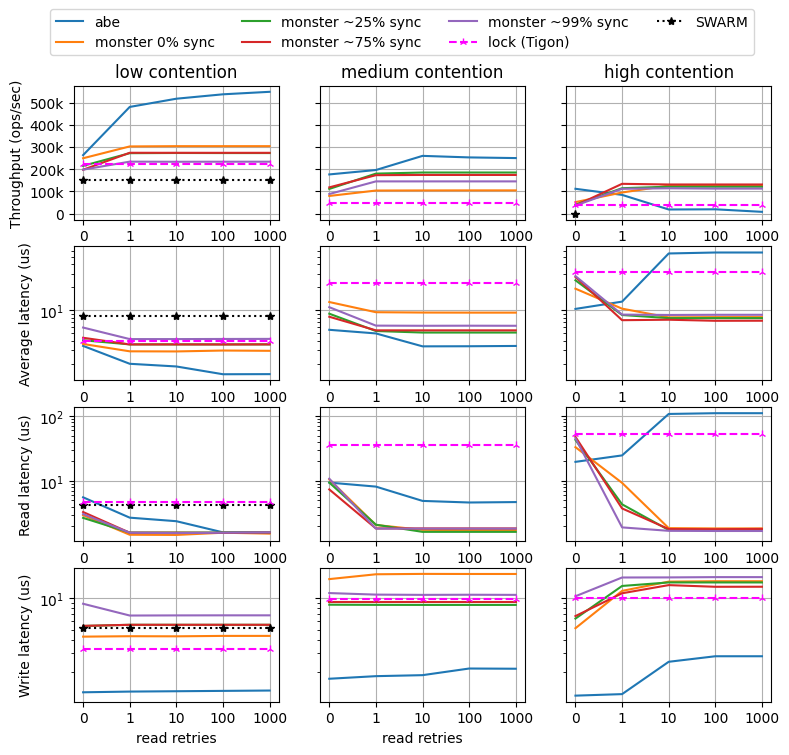

In [13]:
fig, axs = plt.subplots(4,3, sharey="row", figsize=(9, 8))
for ax1 in axs:
    for ax in ax1: 
        ax.grid()
    
# fig.suptitle("YCSB A (50r/50w)")
read_retries_even_space = [0,1,2,3,4]
read_retries_real = [0,1,10,100,1000]
read_retries = read_retries_even_space


ax = axs[0][0]
ax.set_title("low contention")
ax.plot(read_retries, p9_abe_tput, label="abe")
ax.plot(read_retries, p9_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_tput, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_tput, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_tput, label="monster 98% sync")
ax.plot(read_retries, swarm_ib_cloudlab_tput, ':*', color="black",label="SWARM")
ax.plot(read_retries, p9_lock_tput, '--2', color="magenta",label="lock (Tigon)")

ax.set_ylabel("Throughput (ops/sec)")
# ax.set_xscale("log")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)
ax.set_yticks([0, 100000, 200000, 300000, 400000, 500000,600000], 
              labels=["0","100k","200k","300k","400k","500k","600k"])

ax = axs[0][1]
ax.set_title("medium contention")
ax.plot(read_retries, p64_abe_tput, label="abe")
ax.plot(read_retries, p64_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_tput, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_tput, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_tput, label="monster 99% sync")
ax.plot(read_retries, p64_lock_tput, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


ax = axs[0][2]
ax.set_title("high contention")
ax.plot(read_retries, p9sk_abe_tput, label="abe")
ax.plot(read_retries, p9sk_monster10r_tput, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_tput, label="monster ~25% sync")
ax.plot(read_retries, p9sk_monster1500r_tput, label="monster ~75% sync")
ax.plot(read_retries, p9sk_monster2500r_tput, label="monster ~99% sync")
ax.plot(read_retries, p9sk_lock_tput, '--2', color="magenta",label="lock (Tigon)")
ax.plot(0,0,  ':*', color="black", label="SWARM")

# # axtop.set_xticks(read_retries)
ax.legend(loc="center", bbox_to_anchor=(-0.8,1.4), ncols=4)
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


######## avg latency

ax = axs[1][0]
ax.set_yscale("log")

ax.plot(read_retries, p9_abe_avglat, label="abe")
ax.plot(read_retries, p9_monster10r_avglat, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_avglat, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_avglat, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_avglat, label="monster 98% sync")
ax.plot(read_retries, p9_lock_avglat, '--2', color="magenta",label="lock (Tigon)")
ax.plot(read_retries, swarm_ib_cloudlab_avglat, ':*', color="black",label="SWARM")

ax.set_ylabel("Average latency (us)")
ax.set_xlabel("read retries")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


ax = axs[1][1]
ax.plot(read_retries, p64_abe_avglat, label="abe")
ax.plot(read_retries, p64_monster10r_avglat, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_avglat, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_avglat, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_avglat, label="monster 99% sync")
ax.plot(read_retries, p64_lock_avglat, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


ax = axs[1][2]
ax.plot(read_retries, p9sk_abe_avglat, label="abe")
ax.plot(read_retries, p9sk_monster10r_avglat, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_avglat, label="monster 31% sync")
ax.plot(read_retries, p9sk_monster1500r_avglat, label="monster 79% sync")
ax.plot(read_retries, p9sk_monster2500r_avglat, label="monster 99% sync")
ax.plot(read_retries, p9sk_lock_avglat, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)



######## read latency
ax = axs[2][0]
ax.set_yscale("log")

ax.plot(read_retries, p9_abe_rlat, label="abe")
ax.plot(read_retries, p9_monster10r_rlat, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_rlat, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_rlat, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_rlat, label="monster 98% sync")
ax.plot(read_retries, swarm_ib_cloudlab_rlat, ':*', color="black",label="SWARM")

# ax.plot(read_retries, swarm_ib_from_paper, '-', color="black",label="SWARM")
ax.plot(read_retries, p9_lock_rlat, '--2', color="magenta",label="lock (Tigon)")

ax.set_ylabel("Read latency (us)")
ax.set_xlabel("read retries")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


ax = axs[2][1]
ax.plot(read_retries, p64_abe_rlat, label="abe")
ax.plot(read_retries, p64_monster10r_rlat, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_rlat, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_rlat, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_rlat, label="monster 99% sync")
ax.plot(read_retries, p64_lock_rlat, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)

ax = axs[2][2]
ax.plot(read_retries, p9sk_abe_rlat, label="abe")
ax.plot(read_retries, p9sk_monster10r_rlat, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_rlat, label="monster 31% sync")
ax.plot(read_retries, p9sk_monster1500r_rlat, label="monster 79% sync")
ax.plot(read_retries, p9sk_monster2500r_rlat, label="monster 99% sync")
ax.plot(read_retries, p9sk_lock_rlat, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)


#### write latency
ax = axs[3][0]
ax.set_yscale("log")
ax.plot(read_retries, p9_abe_wlat, label="abe")
ax.plot(read_retries, p9_monster10r_wlat, label="monster 0% sync")
ax.plot(read_retries, p9_monster1200r_wlat, label="monster 21% sync")
ax.plot(read_retries, p9_monster1300r_wlat, label="monster 75% sync")
ax.plot(read_retries, p9_monster1700r_wlat, label="monster 98% sync")
ax.plot(read_retries, swarm_ib_cloudlab_wlat, ':*', color="black",label="SWARM")
# ax.plot(read_retries, swarm_ib_from_paper, '-', color="black",label="SWARM")
ax.plot(read_retries, p9_lock_wlat, '--2', color="magenta",label="lock (Tigon)")

ax.set_ylabel("Write latency (us)")
ax.set_xlabel("read retries")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)

ax = axs[3][1]
ax.plot(read_retries, p64_abe_wlat, label="abe")
ax.plot(read_retries, p64_monster10r_wlat, label="monster 0% sync")
ax.plot(read_retries, p64_monster1500r_wlat, label="monster 31% sync")
ax.plot(read_retries, p64_monster2000r_wlat, label="monster 79% sync")
ax.plot(read_retries, p64_monster3100r_wlat, label="monster 99% sync")
ax.plot(read_retries, p64_lock_wlat, '--2', color="magenta", label="lock (Tigon)")
ax.set_xlabel("read retries")
ax.set_xticks(read_retries_even_space, labels=read_retries_real)

ax = axs[3][2]
ax.plot(read_retries, p9sk_abe_wlat, label="abe")
ax.plot(read_retries, p9sk_monster10r_wlat, label="monster 0% sync")
ax.plot(read_retries, p9sk_monster1200r_wlat, label="monster 31% sync")
ax.plot(read_retries, p9sk_monster1500r_wlat, label="monster 79% sync")
ax.plot(read_retries, p9sk_monster2500r_wlat, label="monster 99% sync")
ax.plot(read_retries, p9sk_lock_wlat, '--2', color="magenta", label="lock (Tigon)")
# ax.legend(loc="center", bbox_to_anchor=(0.6,1.4), ncols=5)
# ax.set_xscale("log")
capture_out = ax.set_xticks(read_retries_even_space, labels=read_retries_real)


In [4]:
8*150

1200

## Memory node scale

Scaling the number of nodes for YCSB A workload. The number of nodes impacts the write operations in monster and abe since reads have the first-last-only optimization. 

- read retries: 10
- num of processes: 9

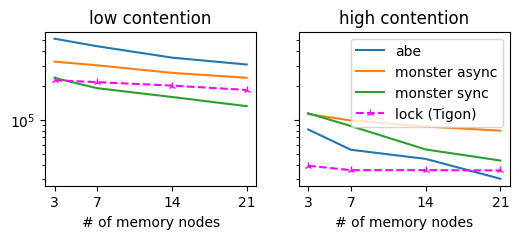

In [4]:
fig, axs = plt.subplots(1,2,figsize=(6, 2), sharey="all")

mnodes = [3,7,14,21]

ax = axs[0]
abe_tput= [517672, 444434, 352620, 306652]
monsterasync_tput = [325026, 301641, 258823, 234177]
monstersync_tput = [233451, 189537, 158530, 131540]
lock_tput = [222723, 214223, 199820, 182842]

ax.set_title("low contention")
ax.plot(mnodes, abe_tput, label="abe")
ax.plot(mnodes, monsterasync_tput, label="monster async")
ax.plot(mnodes, monstersync_tput, label="monster sync")
ax.plot(mnodes, lock_tput, '--2', color="magenta", label="lock (Tigon)")
ax.set_xticks(mnodes)
ax.set_xlabel("# of memory nodes")

ax = axs[1]
abe_tput= [82000, 54285, 45098, 30139]
monsterasync_tput = [112000, 98375, 87000, 80000 ]
monstersync_tput = [ 113875, 87875, 54625, 43625 ]
lock_tput = [39251, 35871, 35871, 35661]

ax.set_title("high contention")
ax.plot(mnodes, abe_tput, label="abe")
ax.plot(mnodes, monsterasync_tput, label="monster async")
ax.plot(mnodes, monstersync_tput, label="monster sync")
ax.plot(mnodes, lock_tput, '--2', color="magenta", label="lock (Tigon)")

ax.set_xlabel("# of memory nodes")
ax.set_xticks(mnodes)
ax.set_yscale("log")
ax.legend()

# Throughput scale
Maximum number of throughput achievable by the system as the number of clients increases.

- 3 memory nodes
- 10 read retries
- workload: YCSB A
- 64B

In [50]:
num_of_clients = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96])
abe_tput_avg = np.array([546062, 526652, 500023, 474240, 449536, 432529, 409675, 393462, 
                384002, 365792, 347056, 329120, 313401, 294271, 279083, 260001, 204117, 
                         188186, 168308, 155518, 143587])
abe_tput_total_Mops = num_of_clients * abe_tput_avg / 1_000_000

monster1300r_tput_avg = np.array([263015, 260025, 256233, 250955, 241714, 236316, 230709, 
                                 225870, 224414, 219263, 209480, 203697, 197392, 190755,
                                 184823, 172462, 86681, 78885, 64406, 50240, 45088])
monster1300r_tput_total_Mops = num_of_clients * monster1300r_tput_avg / 1_000_000

lock_noclients = np.array([4,8,12,20,28,36,44,48,56,64,72,80,88,96])
lock_tput_avg = np.array([225226, 223733, 222660, 210817, 197153, 
                          155133, 95229, 80573, 58576, 45432, 28467, 
                          21637, 18712, 16691])
lock_tput_total_Mops = lock_noclients * lock_tput_avg / 1_000_000 

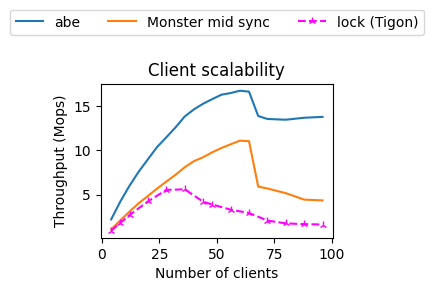

In [51]:
fig, axs = plt.subplots(1,1, figsize=(3, 2), sharey="all")

ax = axs
ax.set_title("Client scalability")
ax.set_xlabel("Number of clients")
ax.set_ylabel("Throughput (Mops)")
ax.plot(num_of_clients, abe_tput_total_Mops, label="abe")
ax.plot(num_of_clients, monster1300r_tput_total_Mops, label="Monster mid sync")
ax.plot(lock_noclients, lock_tput_total_Mops, '--2', color="magenta", label="lock (Tigon)")

ax.legend(loc="center", bbox_to_anchor=(0.5,1.4), ncols=4)



# Object size

- 3 memory nodes
- 10 read retries
- Workload A
- 8 processes